In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
data=pd.read_csv('/content/tea_vs_coffee_global_final.csv',parse_dates=['year'],index_col='year')
data.head()

,country,continent,age,gender,income_level,drink_preference,favorite_drink,drink_category,cups_per_day,drink_temperature,...,exercise_frequency,bmi,hydration_level,heart_rate,drink_reason,social_setting,time_of_day,loyalty_brand,experiment_new_drinks,satisfaction_level
year,,,,,,,,,,,,,,,,,,,,,
2015-01-01,Bangladesh,Asia,56,Male,Low,Coffee,Mocha,Modern,2.3,Both,...,Moderate,26.9,9,86,Taste,Work,Afternoon,Explorer,No,3
2015-01-01,Bangladesh,Asia,61,Other,High,Tea,Oolong Tea,Traditional,1.3,Both,...,High,20.9,1,95,Habit,Family,Night,Explorer,No,6
2015-01-01,Bangladesh,Asia,59,Female,Low,Coffee,Americano,Modern,3.2,Cold,...,Low,31.6,1,84,Taste,Alone,Night,Brand Loyal,No,8
2015-01-01,Bangladesh,Asia,41,Other,High,Coffee,Cappuccino,Modern,3.0,Cold,...,Moderate,33.1,1,94,Energy,Work,Afternoon,Brand Loyal,Yes,5
2015-01-01,Bangladesh,Asia,43,Other,Middle,Tea,Green Tea,Traditional,1.9,Hot,...,High,29.8,2,65,Social,Family,Night,Explorer,No,7


In [23]:
resampled_data = data['cups_per_day'].resample('YE').mean().to_frame()
resampled_data.index = resampled_data.index.year
resampled_data.reset_index(inplace=True)
resampled_data.rename(columns={'year': 'Year', 'cups_per_day': 'cups_per_day_yearly_mean'}, inplace=True)
years = resampled_data['Year'].tolist()
cups_per_day_values = resampled_data['cups_per_day_yearly_mean'].tolist()

In [25]:
X = [i - years[len(years) // 2] for i in years]
x2 = [i ** 2 for i in X]
xy = [i * j for i, j in zip(X, cups_per_day_values)]
n = len(years)

if n < 2:
    # Cannot calculate a meaningful linear regression with less than 2 data points.
    # For n=1, define slope as 0 and intercept as the single data point's value.
    b = 0.0
    a = cups_per_day_values[0] if n == 1 else 0.0
    linear_trend = [a + b * x_val for x_val in X]
else:
    b = (n * sum(xy) - sum(cups_per_day_values) * sum(X)) / (n * sum(x2) - (sum(X) ** 2))
    a = (sum(cups_per_day_values) - b * sum(X)) / n
    linear_trend = [a + b * X[i] for i in range(n)]

In [29]:
# Re-calculating X, x2, xy, n to ensure consistency
X = [i - years[len(years) // 2] for i in years]
x2 = [i ** 2 for i in X]
xy = [i * j for i, j in zip(X, cups_per_day_values)]
n = len(years)

x3 = [i ** 3 for i in X]
x4 = [i ** 4 for i in X]
x2y = [i * j for i, j in zip(x2, cups_per_day_values)]

if n < 3:
    # Cannot calculate a meaningful polynomial regression with less than 3 data points.
    # For n=1 or n=2, define coefficients for a constant trend equal to the mean.
    a_poly = cups_per_day_values[0] if n > 0 else 0.0
    b_poly = 0.0
    c_poly = 0.0
else:
    coeff = [[len(X), sum(X), sum(x2)],
    [sum(X), sum(x2), sum(x3)],
    [sum(x2), sum(x3), sum(x4)]]
    Y = [sum(cups_per_day_values), sum(xy), sum(x2y)]
    A = np.array(coeff)
    B = np.array(Y)
    solution = np.linalg.solve(A, B)
    a_poly, b_poly, c_poly = solution

poly_trend = [a_poly + b_poly * X[i] + c_poly * (X[i] ** 2) for i in range(n)]

Linear Trend: y=2.51 + 0.00x

Polynomial Trend: y=2.51 + 0.01x + 0.00x²


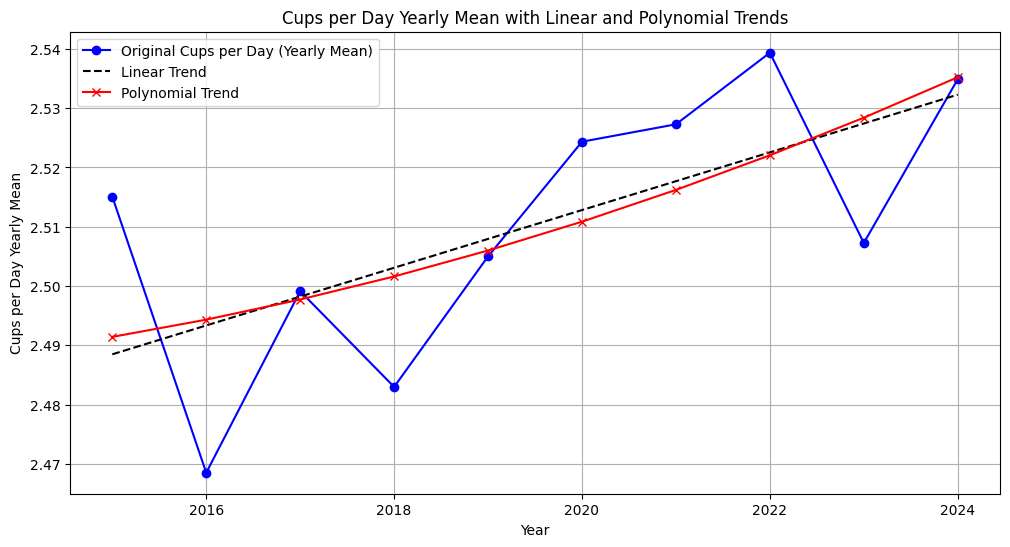

In [31]:
# Linear trend estimation
X = [i - years[len(years) // 2] for i in years]
x2 = [i ** 2 for i in X]
xy = [i * j for i, j in zip(X, cups_per_day_values)]
n = len(years)

if n < 2:
    b = 0.0
    a = cups_per_day_values[0] if n == 1 else 0.0
    linear_trend = [a + b * x_val for x_val in X]
else:
    b = (n * sum(xy) - sum(cups_per_day_values) * sum(X)) / (n * sum(x2) - (sum(X) ** 2))
    a = (sum(cups_per_day_values) - b * sum(X)) / n
    linear_trend = [a + b * X[i] for i in range(n)]

# Polynomial trend estimation
x3 = [i ** 3 for i in X]
x4 = [i ** 4 for i in X]
x2y = [i * j for i, j in zip(x2, cups_per_day_values)]

if n < 3:
    a_poly = cups_per_day_values[0] if n > 0 else 0.0
    b_poly = 0.0
    c_poly = 0.0
else:
    coeff = [[len(X), sum(X), sum(x2)],
    [sum(X), sum(x2), sum(x3)],
    [sum(x2), sum(x3), sum(x4)]]
    Y = [sum(cups_per_day_values), sum(xy), sum(x2y)]
    A = np.array(coeff)
    B = np.array(Y)
    solution = np.linalg.solve(A, B)
    a_poly, b_poly, c_poly = solution

poly_trend = [a_poly + b_poly * X[i] + c_poly * (X[i] ** 2) for i in range(n)]

print(f"Linear Trend: y={a:.2f} + {b:.2f}x")
print(f"\nPolynomial Trend: y={a_poly:.2f} + {b_poly:.2f}x + {c_poly:.2f}x²")
resampled_data['Linear Trend'] = linear_trend
resampled_data['Polynomial Trend'] = poly_trend
resampled_data.set_index('Year',inplace=True)

plt.figure(figsize=(12, 6))
resampled_data['cups_per_day_yearly_mean'].plot(kind='line',color='blue',marker='o', label='Original Cups per Day (Yearly Mean)')
resampled_data['Linear Trend'].plot(kind='line',color='black',linestyle='--', label='Linear Trend')
resampled_data['Polynomial Trend'].plot(kind='line',color='red',marker='x', label='Polynomial Trend')
plt.title('Cups per Day Yearly Mean with Linear and Polynomial Trends')
plt.xlabel('Year')
plt.ylabel('Cups per Day Yearly Mean')
plt.legend()
plt.grid(True)
plt.show()